# Indigo Airlines - Customer Booking Analysis

### ~ Set up Libraries and Load data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("libraries imported successfully!")

libraries imported successfully!


In [5]:
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

### ~ Data loading and cleaning 


In [6]:
df = pd.read_csv('Indigo-customer-booking-raw-data.csv')
df = df.dropna(subset=['Flight number']).reset_index(drop=True)
print("data loaded successfully!")

data loaded successfully!


In [7]:
print(df.shape)
print(df.isna().sum())
print(df['booking_complete'].describe())

(50000, 18)
Flight number               0
num_passengers              0
sales_channel               0
trip_type                   0
purchase_lead               0
length_of_stay              0
flight_hour                 0
flight_day                  0
route                       0
booking_origin              0
wants_extra_baggage         0
wants_preferred_seat        0
wants_in_flight_meals       0
flight_duration_planned    13
booking_complete           36
flight duration actual     15
Seat class                  0
booking amount              0
dtype: int64
count    49964.000000
mean         0.148947
std          0.356040
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: booking_complete, dtype: float64


In [8]:
df.columns.tolist()
df.dtypes

Flight number              float64
num_passengers             float64
sales_channel                  str
trip_type                      str
purchase_lead              float64
length_of_stay             float64
flight_hour                float64
flight_day                     str
route                          str
booking_origin                 str
wants_extra_baggage        float64
wants_preferred_seat       float64
wants_in_flight_meals      float64
flight_duration_planned    float64
booking_complete           float64
flight duration actual     float64
Seat class                     str
booking amount             float64
dtype: object

In [9]:
# Replace placeholder text with proper NaN
df['sales_channel'] = df['sales_channel'].replace('{no data}', np.nan)

# Verify
print("Remaining {no data}:", (df['sales_channel'] == '{no data}').sum())
print("NaN in sales_channel:", df['sales_channel'].isna().sum())

Remaining {no data}: 0
NaN in sales_channel: 59


In [10]:
# Rename Columns for Consistency
df.rename(columns={
    'flight duration actual': 'flight_duration_actual',
    'Seat class': 'seat_class',
    'booking amount': 'booking_amount'},inplace=True) 
print("columns renamed successfully!")

df.head()

columns renamed successfully!


,Flight number,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration_planned,booking_complete,flight_duration_actual,seat_class,booking_amount
0,101.0,2.0,Internet,RoundTrip,262.0,19.0,7.0,Sat,AKLDEL,New Zealand,1.0,0.0,0.0,5.52,0.0,6.7,Economy,0.0
1,102.0,1.0,Internet,RoundTrip,112.0,20.0,3.0,Sat,AKLDEL,New Zealand,0.0,0.0,0.0,5.52,0.0,6.7,Premium Economy,0.0
2,103.0,2.0,Internet,RoundTrip,243.0,22.0,17.0,Wed,AKLDEL,India,1.0,1.0,0.0,5.52,0.0,6.7,Business,0.0
3,104.0,1.0,Internet,RoundTrip,96.0,31.0,4.0,Sat,AKLDEL,New Zealand,0.0,0.0,1.0,5.52,0.0,6.7,Economy,0.0
4,105.0,2.0,Internet,RoundTrip,68.0,22.0,15.0,Wed,AKLDEL,India,1.0,0.0,1.0,5.52,0.0,6.7,Premium Economy,0.0


In [11]:
# Missing Values Analysis
missing_values = df.isnull().sum()
missing_values_percent = df.isnull().sum() / len(df) * 100
df[df.isnull().any(axis=1)]
missing_values_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_values_percent.round(2)
})
print("Missing Values Summary:\n", missing_values_summary)

Missing Values Summary:
                          Missing Count  Missing %
Flight number                        0       0.00
num_passengers                       0       0.00
sales_channel                       59       0.12
trip_type                            0       0.00
purchase_lead                        0       0.00
length_of_stay                       0       0.00
flight_hour                          0       0.00
flight_day                           0       0.00
route                                0       0.00
booking_origin                       0       0.00
wants_extra_baggage                  0       0.00
wants_preferred_seat                 0       0.00
wants_in_flight_meals                0       0.00
flight_duration_planned             13       0.03
booking_complete                    36       0.07
flight_duration_actual              15       0.03
seat_class                           0       0.00
booking_amount                       0       0.00


In [12]:
# Fix data types

# Convert normal categorical columns to category type
category_columns = ['sales_channel','trip_type','seat_class','booking_origin','route']

for col in category_columns:
    df[col] = df[col].astype('category')


# Convert flight_day into ordered category
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['flight_day'] = pd.Categorical(df['flight_day'],categories=day_order,ordered=True)

# Convert binary columns to integer type
binary_columns = ['wants_extra_baggage','wants_preferred_seat','wants_in_flight_meals','booking_complete']

for col in binary_columns:
    df[col] = df[col].fillna(0).astype('int64')

print("Data types after conversion:\n", df.dtypes)

Data types after conversion:
 Flight number               float64
num_passengers              float64
sales_channel              category
trip_type                  category
purchase_lead               float64
length_of_stay              float64
flight_hour                 float64
flight_day                 category
route                      category
booking_origin             category
wants_extra_baggage           int64
wants_preferred_seat          int64
wants_in_flight_meals         int64
flight_duration_planned     float64
booking_complete              int64
flight_duration_actual      float64
seat_class                 category
booking_amount              float64
dtype: object


### ~ EDA - Exploratory Data Analysis

Data Types Reference

| Column | Data Type | Category |
|---|---|---|
| `flight_duration_planned` | Numerical **Continuous** | Decimal hours — can take any fractional value |
| `flight_duration_actual` | Numerical **Continuous** | Same |
| `booking_amount` | Numerical **Continuous** | Can be any positive decimal |
| `purchase_lead` | Numerical **Discrete** | Whole days |
| `length_of_stay` | Numerical **Discrete** | Whole days |
| `flight_hour` | Numerical **Discrete** | Integer 0–23 |
| `num_passengers` | Numerical **Discrete** | Countable whole number |
| `flight_day` | **Ordinal Categorical** | Mon < Tue < … < Sun (ordered) |
| `seat_class` | **Nominal Categorical** | Economy / Premium Economy / Business |
| `sales_channel` | **Nominal Categorical** | Internet / Mobile |
| `trip_type` | **Nominal Categorical** | RoundTrip / OneWay / CircleTrip |
| `wants_extra_baggage` | **Binary (0/1)** | Best treated as nominal categorical |
| `wants_preferred_seat` | **Binary (0/1)** | Same |
| `wants_in_flight_meals` | **Binary (0/1)** | Same |
| `booking_complete` | **Binary (0/1)** | Same |

In [13]:
# Numerical columns distribution

numerical_columns = ['purchase_lead','length_of_stay','flight_hour',
                     'flight_duration_planned','flight_duration_actual','booking_amount']
df[numerical_columns].describe().round(2)

,purchase_lead,length_of_stay,flight_hour,flight_duration_planned,flight_duration_actual,booking_amount
count,50000.00,50000.00,50000.00,49987.00,49985.00,50000.00
mean,84.94,23.04,9.07,7.28,8.37,3668.32
std,90.45,33.89,5.41,1.50,1.41,9768.93
min,0.00,0.00,0.00,4.67,5.30,0.00
25%,21.00,5.00,5.00,5.62,6.90,0.00
50%,51.00,17.00,9.00,7.57,9.10,0.00
75%,115.00,28.00,13.00,8.83,9.50,0.00
max,867.00,778.00,23.00,9.50,9.80,91651.00


In [14]:
#Categorical columns Distribution

df['trip_type'] = df['trip_type'].replace({
    'RoundOnewayTrip': 'RoundTrip',
    'RoundTripRoundOnewayTrip': 'RoundTrip'})

trip_type_counts = df['trip_type'].value_counts()
seat_class_counts = df['seat_class'].value_counts()
sales_channel_counts = df['sales_channel'].value_counts()

trip_type_count_percent = df['trip_type'].value_counts(normalize=True) * 100
seat_class_count_percent = df['seat_class'].value_counts(normalize=True) * 100  
sales_channel_count_percent = df['sales_channel'].value_counts(normalize=True) * 100

print("Trip Type Value Counts:\n", trip_type_counts)
print("\nSeat Class Value Counts:\n", seat_class_counts)    
print("\nSales Channel Value Counts:\n", sales_channel_counts)
print("\nTrip Type Value Counts (%):\n", trip_type_count_percent)
print("\nSeat Class Value Counts (%):\n", seat_class_count_percent) 
print("\nSales Channel Value Counts (%):\n", sales_channel_count_percent) 

Trip Type Value Counts:
 trip_type
RoundTrip                   49497
OneWay                        387
CircleTrip                    116
RoundOnewayTrip                 0
RoundTripRoundOnewayTrip        0
Name: count, dtype: int64

Seat Class Value Counts:
 seat_class
Economy            16667
Premium Economy    16667
Business           16666
Name: count, dtype: int64

Sales Channel Value Counts:
 sales_channel
Internet    44327
Mobile       5614
Name: count, dtype: int64

Trip Type Value Counts (%):
 trip_type
RoundTrip                   98.994
OneWay                       0.774
CircleTrip                   0.232
RoundOnewayTrip              0.000
RoundTripRoundOnewayTrip     0.000
Name: proportion, dtype: float64

Seat Class Value Counts (%):
 seat_class
Economy            33.334
Premium Economy    33.334
Business           33.332
Name: proportion, dtype: float64

Sales Channel Value Counts (%):
 sales_channel
Internet    88.758735
Mobile      11.241265
Name: proportion, dtype: float6

In [15]:
# Check outliers specifically
df['length_of_stay'].sort_values(ascending=False).head(10)

10821    778.0
22081    773.0
10294    610.0
1583     603.0
24154    577.0
21582    573.0
13214    532.0
23179    517.0
13439    513.0
14828    510.0
Name: length_of_stay, dtype: float64

In [16]:
# Check Max and Min values for booking amount
print("Max Booking Amount:", df['booking_amount'].max())
print("Min Booking Amount:", df['booking_amount'].min())

Max Booking Amount: 91651.0
Min Booking Amount: 0.0


In [17]:
# Crete Helper Columns for Analysis

# Booking Status 
df['booking_status'] = df['booking_complete'].apply(lambda x: 'Complete' if x == 1 else 'Incomplete')

# Total Add-on Selected
df['total_add_ons'] = df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals']

# Duration delay
df['Duraion_delay'] = df['flight_duration_actual'] - df['flight_duration_planned']

df.head()

,Flight number,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,...,wants_preferred_seat,wants_in_flight_meals,flight_duration_planned,booking_complete,flight_duration_actual,seat_class,booking_amount,booking_status,total_add_ons,Duraion_delay
0,101.0,2.0,Internet,RoundTrip,262.0,19.0,7.0,Sat,AKLDEL,New Zealand,...,0,0,5.52,0,6.7,Economy,0.0,Incomplete,1,1.18
1,102.0,1.0,Internet,RoundTrip,112.0,20.0,3.0,Sat,AKLDEL,New Zealand,...,0,0,5.52,0,6.7,Premium Economy,0.0,Incomplete,0,1.18
2,103.0,2.0,Internet,RoundTrip,243.0,22.0,17.0,Wed,AKLDEL,India,...,1,0,5.52,0,6.7,Business,0.0,Incomplete,2,1.18
3,104.0,1.0,Internet,RoundTrip,96.0,31.0,4.0,Sat,AKLDEL,New Zealand,...,0,1,5.52,0,6.7,Economy,0.0,Incomplete,1,1.18
4,105.0,2.0,Internet,RoundTrip,68.0,22.0,15.0,Wed,AKLDEL,India,...,0,1,5.52,0,6.7,Premium Economy,0.0,Incomplete,2,1.18


In [18]:
# split complete and incomplete bookings for separate analysis
df_complete   = df[df['booking_complete'] == 1]   
df_incomplete = df[df['booking_complete'] == 0]   

print("Complete Bookings:", df_complete.shape[0])
print("Incomplete Bookings:", df_incomplete.shape[0])   

Complete Bookings: 7442
Incomplete Bookings: 42558


### ~ Top Level Metrics Calculation 

***Metrics Tree***
```
TOTAL REVENUE (Top-Level Metric)
│
├── Booking Volume
│   ├── Total Bookings Attempted
│   ├── Completed Bookings
│   └── Booking Completion Rate
│
├── Average Booking Value 
│   ├── By Seat Class   (Economy / Premium Economy / Business)
│   ├── By Sales Channel (Internet / Mobile)
│   └── By Trip Type    (RoundTrip / OneWay / CircleTrip)
│
└── Add-on Attachment Rates  (behaviour - full dataset)
    ├── Extra Baggage Rate
    ├── Preferred Seat Rate
    └── In-flight Meal Rate
```


In [19]:
# All from df_complete (Complete Bookings)

total_revenue = df_complete['booking_amount'].sum().round()
total_bookings = len(df_complete)
avg_booking_amount = (df_complete['booking_amount'].mean().round(2))
completion_rate = total_bookings / len(df) * 100

# Add-on rates use full df (behaviour analysis — includes both complete and incomplete)
# This shows customer intent regardless of whether they completed booking
baggage_rate = df['wants_extra_baggage'].mean() * 100
seat_rate = df['wants_preferred_seat'].mean() * 100
meal_rate = df['wants_in_flight_meals'].mean() * 100

print("Total Revenue from Complete Bookings:", total_revenue)
print("Total Complete Bookings:", total_bookings)               
print("Average Booking Amount (Complete Bookings):", avg_booking_amount)
print("Booking Completion Rate:", completion_rate, "%")
print("Add-on Attachment Rates:")
print(" - Extra Baggage:", baggage_rate, "%")
print(" - Preferred Seat:", seat_rate, "%")
print(" - In-flight Meals:", meal_rate, "%")    


Total Revenue from Complete Bookings: 182481572.0
Total Complete Bookings: 7442
Average Booking Amount (Complete Bookings): 24520.5
Booking Completion Rate: 14.884 %
Add-on Attachment Rates:
 - Extra Baggage: 66.878 %
 - Preferred Seat: 29.696 %
 - In-flight Meals: 42.714 %


### ~Revenue Breakdown and Visualization


### 1.  Revenue by Seat class

In [20]:
# by seat_class
seat_summary = (df_complete.groupby('seat_class')['booking_amount'].agg(['count','sum','mean']).reset_index())

# convert sum and mean to whole numbers 
seat_summary['sum'] = seat_summary['sum'].round(0).astype(int)
seat_summary['mean'] = seat_summary['mean'].round(0).astype(int)

print(seat_summary)

        seat_class  count       sum   mean
0         Business   2464  76371344  30995
1          Economy   2490  44768846  17979
2  Premium Economy   2488  61341382  24655


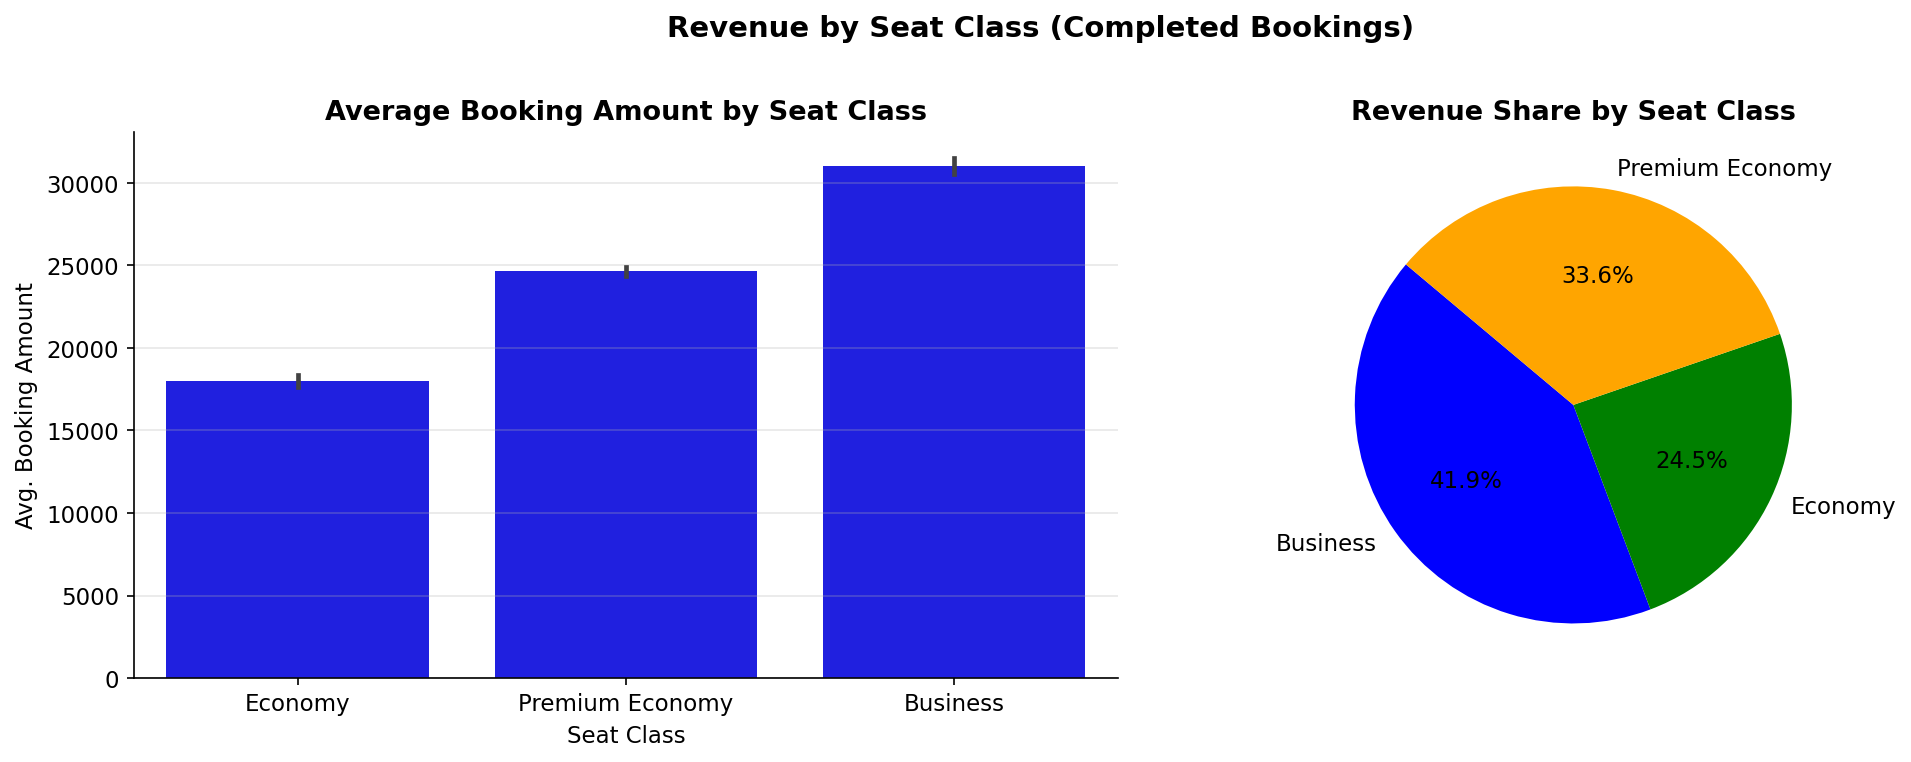

chart saved successfully!


In [21]:
# Combined Chart for Average Booking Amount and Revenue Share by Seat Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue by Seat Class (Completed Bookings)', fontsize=14, fontweight='bold', y=1.01)

# ---------Left Side: Average Booking Amount by Seat Class---------
order = ['Economy', 'Premium Economy', 'Business']  
sns.barplot(x='seat_class', y='booking_amount', data=df_complete,
            order=order, estimator=np.mean, color='blue', ax=axes[0])
axes[0].set_title('Average Booking Amount by Seat Class')
axes[0].set_xlabel('Seat Class')
axes[0].set_ylabel('Avg. Booking Amount')


# ----------Right side: Revenue Share by Seat Class---------
axes[1].pie(seat_summary['sum'],
            labels=seat_summary['seat_class'],
            autopct='%1.1f%%', startangle=140,
            colors=['Blue','Green','Orange'])
axes[1].set_title('Revenue Share by Seat Class')

plt.tight_layout()
plt.savefig('chart_01_seat_class.png', bbox_inches='tight')
plt.show()  

print('chart saved successfully!')

### 2. Revenue by sales channel

In [22]:
# summary by sales channel
sales_channel_summary = (df_complete.groupby('sales_channel')['booking_amount']. agg(['count','sum','mean']).reset_index())

# convert sum and mean to whole numbers 
sales_channel_summary['sum'] = sales_channel_summary['sum'].round(0).astype(int)
sales_channel_summary['mean'] = sales_channel_summary['mean'].round(0).astype(int)

print(sales_channel_summary)

  sales_channel  count        sum   mean
0      Internet   6830  167230338  24485
1        Mobile    607   15173094  24997


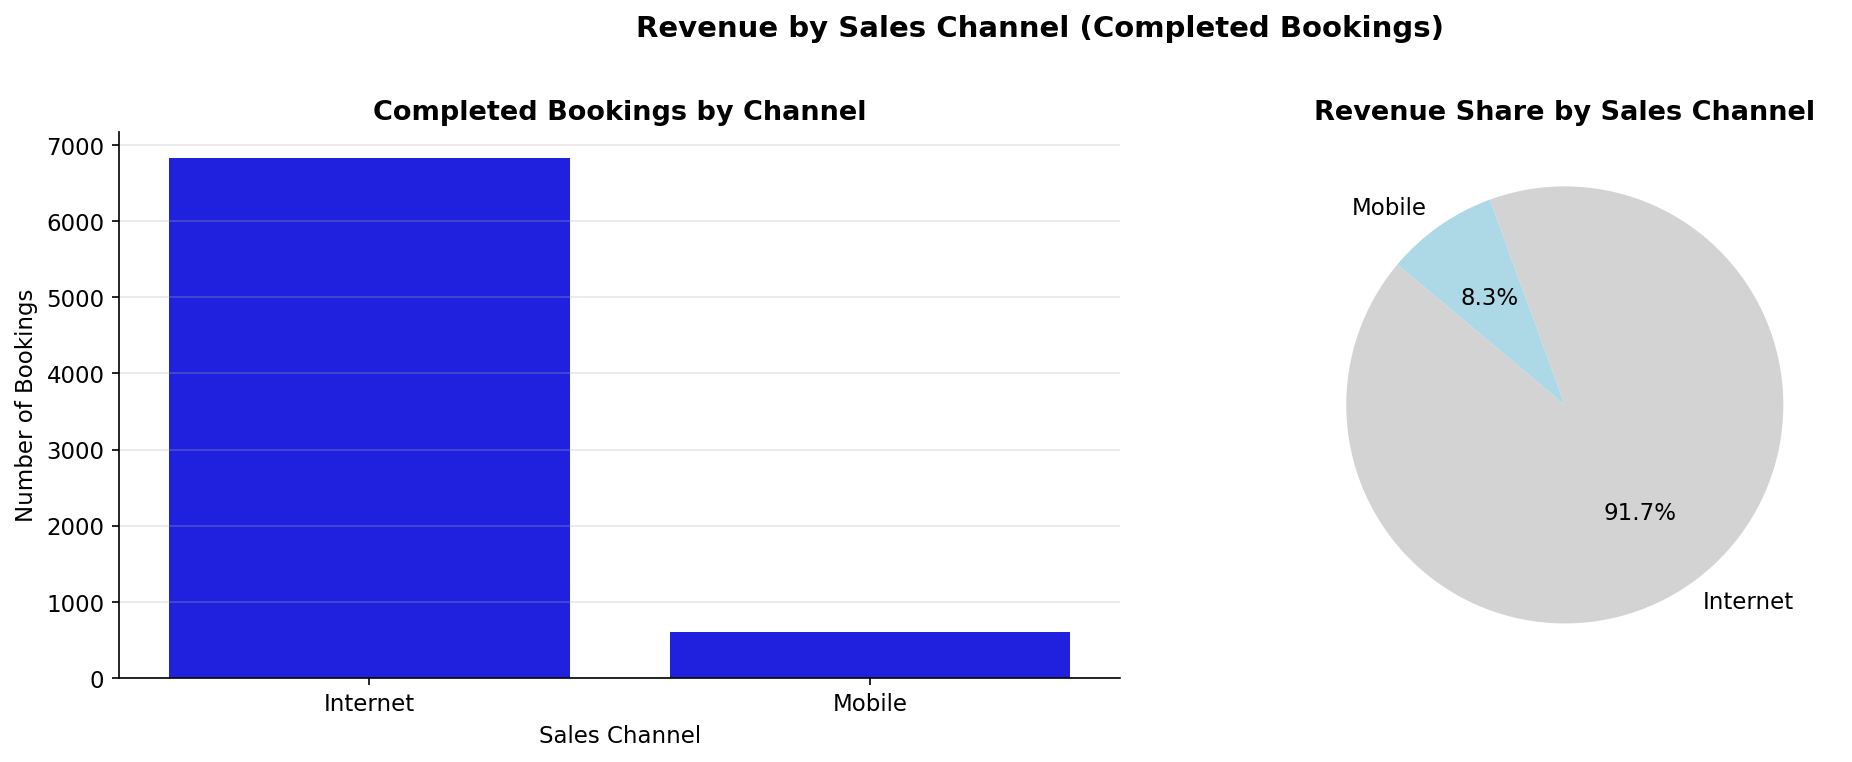

Chart saved successfully!


In [23]:
# ── Chart ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue by Sales Channel (Completed Bookings)', fontsize=14, fontweight='bold', y=1.01)

# ------------- Left: bar — booking counts -----------------
sns.countplot(x='sales_channel', data=df_complete, color='blue',
              order=sales_channel_summary['sales_channel'], ax=axes[0])
axes[0].set_title('Completed Bookings by Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Number of Bookings')

# ------------- Right: pie — revenue share -----------------
axes[1].pie(sales_channel_summary['sum'],
            labels=sales_channel_summary['sales_channel'],              
            autopct='%1.1f%%', startangle=140,
            colors=['lightgrey', 'lightblue'])
axes[1].set_title('Revenue Share by Sales Channel')

plt.tight_layout()
plt.savefig('chart_02_sales_channel.png', bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

> ** Observation — Sales Channel:**  
> The Internet channel dominates, generating ~92% of total revenue and ~92% of completed bookings.  
> Mobile is a distant second. This is a critical finding - any disruption to the web platform would severely impact revenue.  
> The small **NaN** group (missing channel data) should be investigated in future data collection.

### 3. Revenue by trip type 

In [24]:
# by trip_type
trip_type_summary = (df_complete.groupby('trip_type')['booking_amount'].agg(['count','sum','mean']).reset_index())

# convert sum and mean to whole numbers 
trip_type_summary['sum'] = trip_type_summary['sum'].round(0).astype(int)
trip_type_summary['mean'] = trip_type_summary['mean'].round(0).astype(int)

print(trip_type_summary)

    trip_type  count        sum   mean
0  CircleTrip      5     112547  22509
1      OneWay     20     178160   8908
2   RoundTrip   7417  182190866  24564


### 4. Revenue by flight day

In [25]:
# by day of week
flight_day_summary = (df_complete.groupby('flight_day')['booking_amount'].agg(['count','sum','mean']).reset_index())

# convert sum and mean to whole numbers 
flight_day_summary['sum'] = flight_day_summary['sum'].round(0).astype(int)
flight_day_summary['mean'] = flight_day_summary['mean'].round(0).astype(int)

print(flight_day_summary)

  flight_day  count       sum   mean
0        Mon   1198  28167140  23512
1        Tue   1119  26028125  23260
2        Wed   1250  28889440  23112
3        Thu   1118  26071484  23320
4        Fri    978  22983189  23500
5        Sat    859  23828296  27740
6        Sun    920  26513899  28819


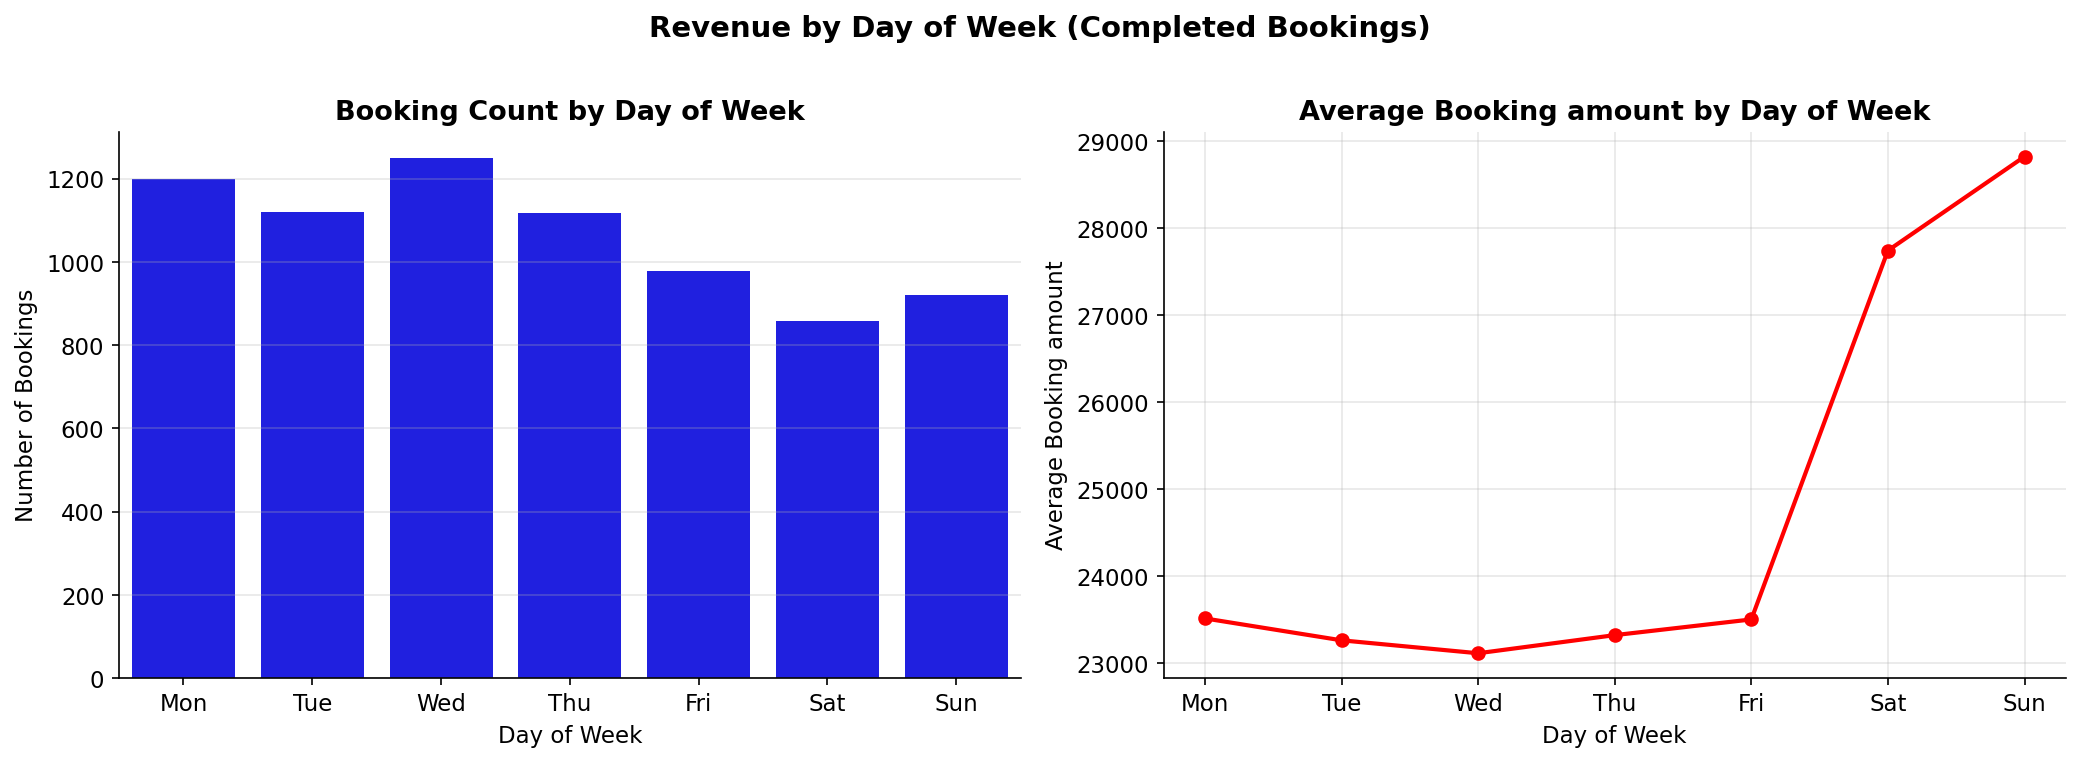

chart saved successfully!


In [26]:
# combined chart for booking count and revenue by day of week   
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue by Day of Week (Completed Bookings)', fontsize=14, fontweight='bold', y=1.01)

# --------------Left Side: Booking Count by Day of Week-----------------
sns.countplot(x='flight_day', data=df_complete, order=day_order, color='blue',ax=axes[0])
axes[0].set_title('Booking Count by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Bookings')


# ----------Right side: Revenue Share by Day of Week---------
avg_days_vals = df_complete.groupby('flight_day', observed=True)['booking_amount'].mean().reindex(day_order)
axes[1].plot(day_order, avg_days_vals, marker='o', color='red', linewidth=2)
axes[1].set_title('Average Booking amount by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Booking amount')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('Chart_3_Flight_Day_of_Week.png', bbox_inches='tight')
plt.show()

print('chart saved successfully!')

> **Observation - Flight Day:**  
> Booking counts are broadly similar across all days of the week, with no dramatic peaks or troughs.  
> Average booking amounts also show little variation by day.  
> This suggests flight day is **not a meaningful driver** of revenue or booking volume - pricing strategies do not need to vary by day.

## 5. Revenue by Add-on count

In [27]:
addon_summary = (df_complete
    .groupby('total_add_ons')['booking_amount']
    .agg(Bookings='count', Avg_Amount='mean')
    .reset_index())
addon_summary['Avg_Amount'] = addon_summary['Avg_Amount'].round(0).astype(int)
print(addon_summary.to_string(index=False))

 total_add_ons  Bookings  Avg_Amount
             0      1107       16633
             1      2717       23649
             2      1993       27085
             3      1625       28204


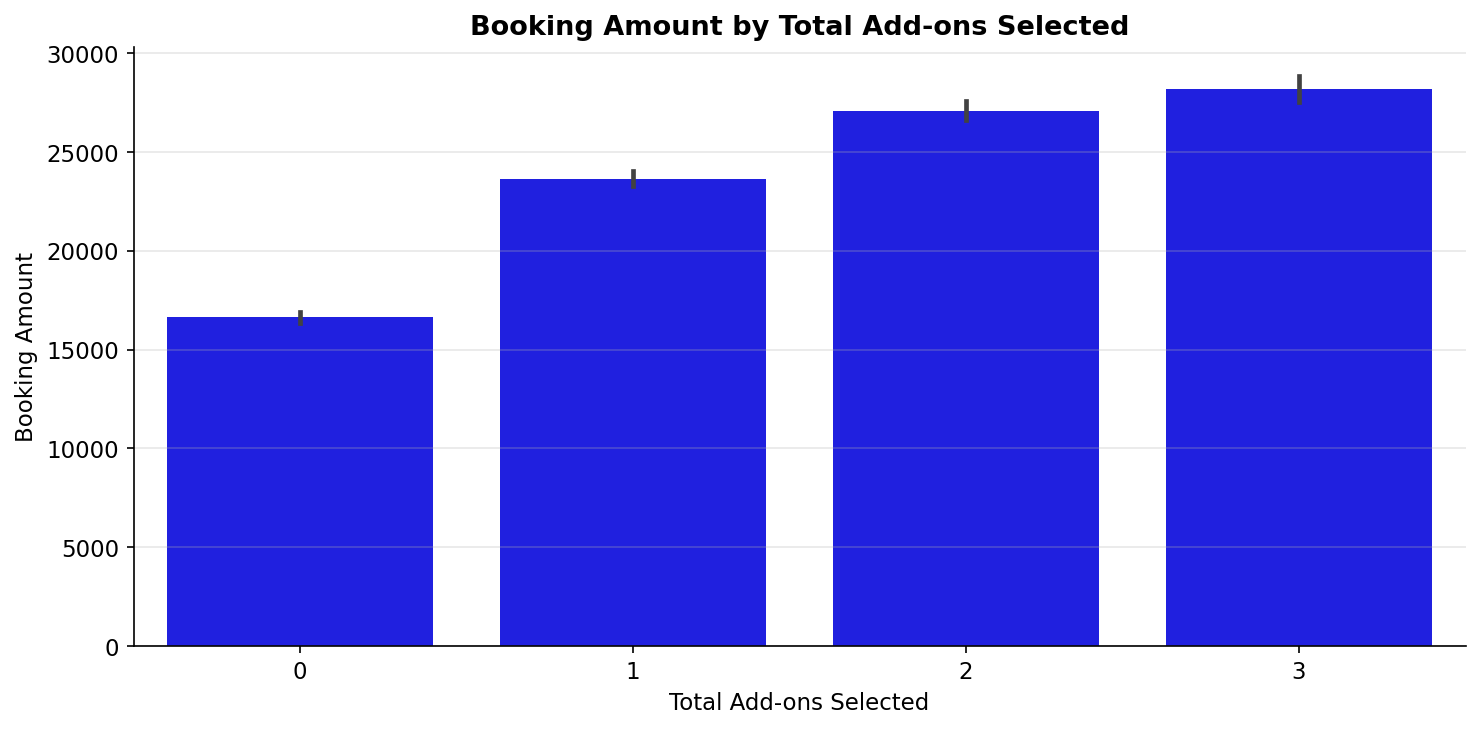

chart saved successfully!


In [28]:
# Add-on attachment rate 
plt.figure(figsize=(10,5))
sns.barplot(x='total_add_ons',y='booking_amount',data=df_complete,color='blue')
plt.title('Booking Amount by Total Add-ons Selected')
plt.xlabel('Total Add-ons Selected')
plt.ylabel('Booking Amount')
plt.tight_layout()
plt.savefig('chart_04_booking_amount_by_total_add_ons.png')  
plt.show()
print('chart saved successfully!')

> **Observation - Add-on:**
> There is a clear positive relationship: customers who select more add-ons tend to pay higher booking amounts.  
> The heatmap shows this pattern holds across all seat classes.  
> Promoting bundled add-on packages is a strong lever for increasing Average Booking Value.

### Hypothesis:1 "Business Class has longer purchase lead time"

In [29]:
# create summary by seat class
purchase_lead_summary =df.groupby('seat_class')['purchase_lead'].describe().round()
print(purchase_lead_summary)

                   count  mean   std  min   25%   50%    75%    max
seat_class                                                         
Business         16666.0  85.0  90.0  0.0  21.0  51.0  114.0  704.0
Economy          16667.0  85.0  90.0  0.0  21.0  51.0  115.0  625.0
Premium Economy  16667.0  85.0  91.0  0.0  21.0  51.0  116.0  867.0


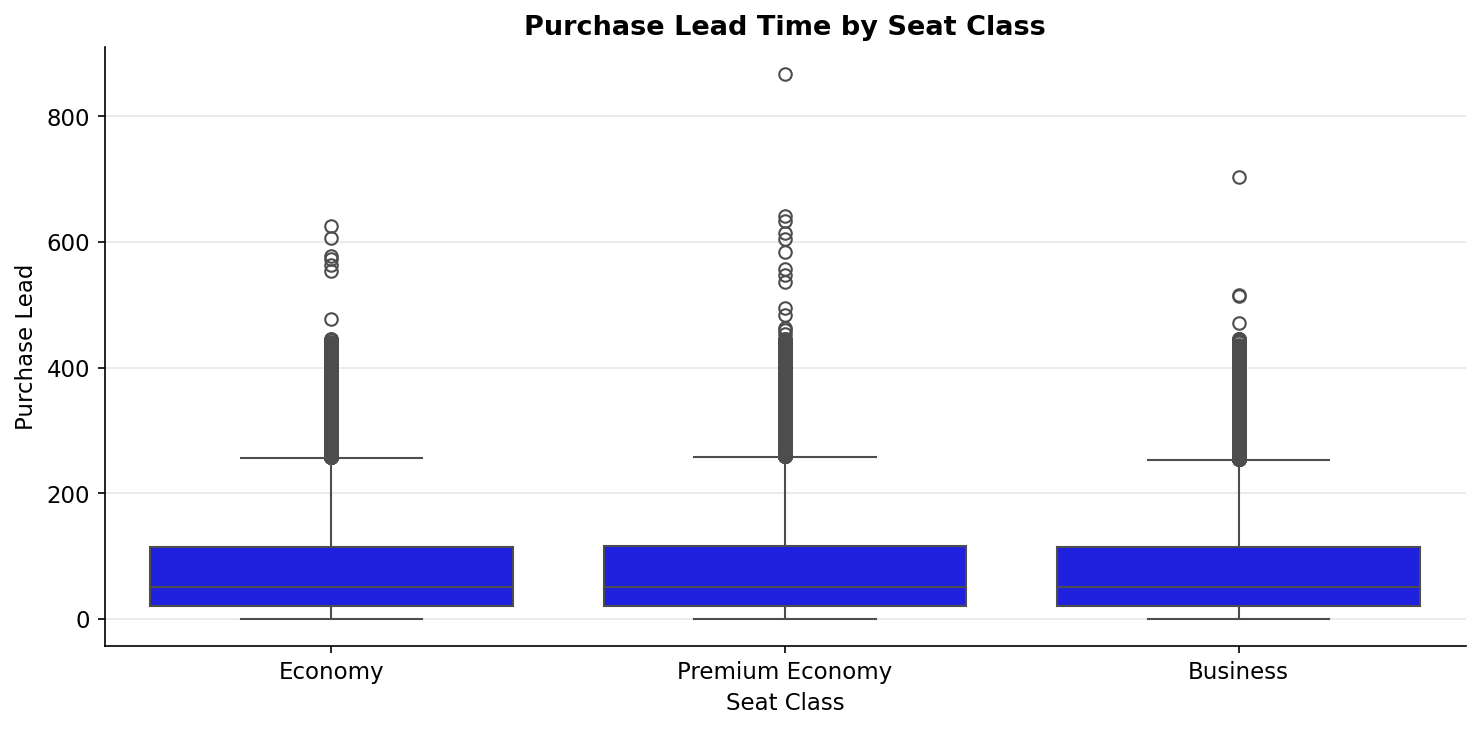

chart saved successfully!


In [30]:
# Boxplot for purchase lead time by seat class
plt.figure(figsize=(10,5))
sns.boxplot(x='seat_class',y='purchase_lead',data=df,order=['Economy','Premium Economy','Business'],color='blue')
plt.title('Purchase Lead Time by Seat Class')
plt.xlabel('Seat Class')    
plt.ylabel('Purchase Lead')
plt.tight_layout()
plt.savefig('chart_05_h1_purchase_lead_time_by_seat_class.png', bbox_inches='tight')
plt.show()
print('chart saved successfully!')

### Observation - Hypothesis 1 ( Not Supported )
The median purchase lead time is roughly similar across Economy, Premium Economy, 
and Business class. This suggests that seat class alone does not strongly predict 
how far in advance a customer books. The hypothesis is NOT strongly supported by the data.

### Hypothesis:2 "Longer length of stay = higher booking amount"

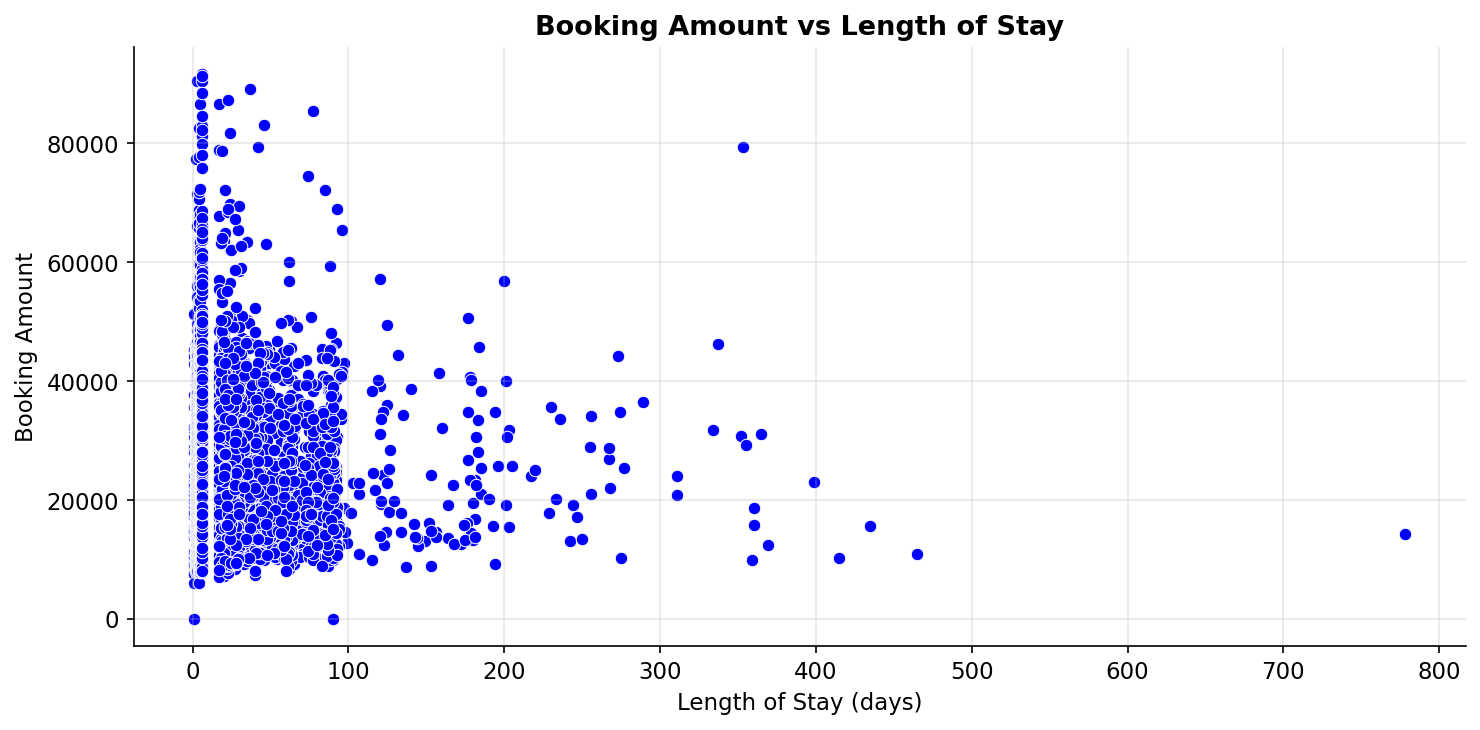

chart saved successfully!


In [31]:
#Scatterplot for booking amount vs length of stay

plt.figure(figsize=(10,5))
sns.scatterplot(x='length_of_stay',y='booking_amount',data=df_complete,color='blue')
plt.title('Booking Amount vs Length of Stay')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Booking Amount')        
plt.tight_layout()
plt.savefig('chart_06_h2_booking_amount_vs_length_of_stay.png', bbox_inches='tight')
plt.show()
print('chart saved successfully!')

In [32]:
# Correlation matrix
correlation = df_complete[['length_of_stay','booking_amount']].corr().round(2)
print("correlation between length of stay and booking amount:\n", correlation)                                        

correlation between length of stay and booking amount:
                 length_of_stay  booking_amount
length_of_stay            1.00            0.01
booking_amount            0.01            1.00


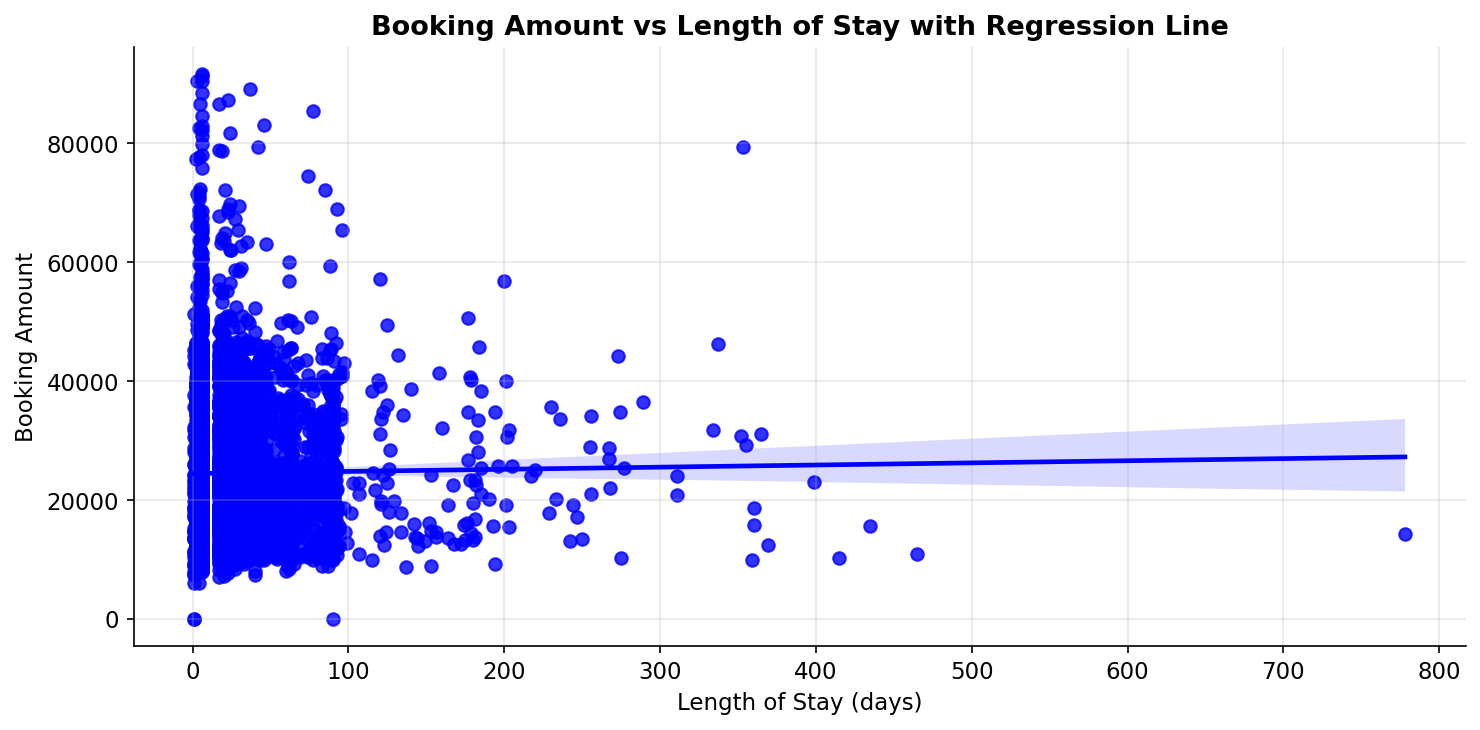

chart saved successfully!


In [33]:
# Regression plot for booking amount vs length of stay
plt.figure(figsize=(10,5))
sns.regplot(x='length_of_stay',y='booking_amount',data=df_complete,color='blue')
plt.title('Booking Amount vs Length of Stay with Regression Line')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Booking Amount')
plt.tight_layout()
plt.savefig('chart_07_h2_booking_amount_vs_length_of_stay_regression.png', bbox_inches='tight')
plt.show()
print('chart saved successfully!')

 ### Obeservation: Hypothesis - 2 ( Not Supported )
 - The correlation between length of stay and booking amount is near zero, indicating no meaningful linear relationship.  
 - The scatter plot confirms the data is spread randomly with no upward trend.  
 - The regression line is nearly flat.

### Hypothesis:3 "Sales channel influences booking amount and behaviour"


In [34]:
# Behavioural comparison
sales_behaviour  = (df.groupby('sales_channel')[['purchase_lead','total_add_ons','length_of_stay']].mean().round(2))
print(sales_behaviour)

               purchase_lead  total_add_ons  length_of_stay
sales_channel                                              
Internet               85.39           1.40           23.79
Mobile                 81.56           1.33           17.30


In [35]:
# Revenue comparison
sales_revenue = (df_complete.groupby('sales_channel')['booking_amount'].agg(['mean', 'median', 'count']).round(0))
sales_revenue


,mean,median,count
sales_channel,,,
Internet,24485.0,22076.0,6830
Mobile,24997.0,22895.0,607


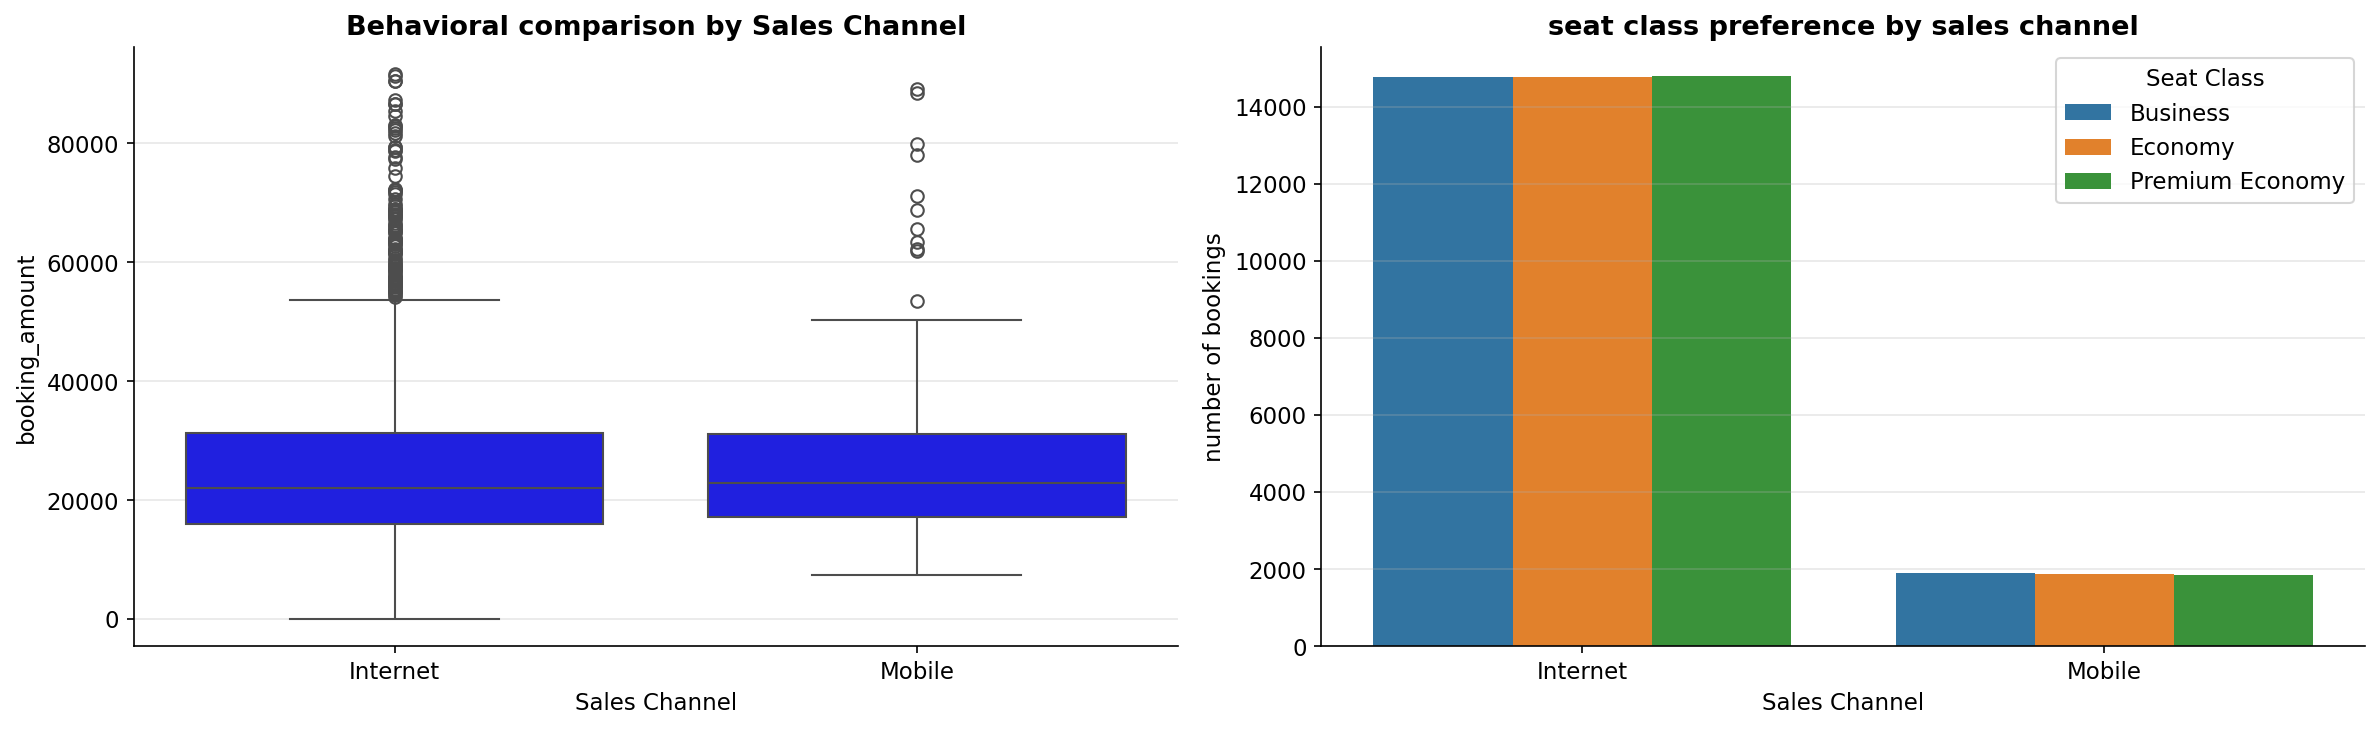

chart saved successfully!


In [36]:

# create group box chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------- Left Side: Box Plot -----------
sns.boxplot(x='sales_channel',y='booking_amount',data=df_complete,color='blue', ax=axes[0])
axes[0].set_title('Behavioral comparison by Sales Channel')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('booking_amount')


# ----------- Right Side: count plot -----------
sns.countplot(x='sales_channel',hue='seat_class',data=df, ax=axes[1])
axes[1].set_title('seat class preference by sales channel')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('number of bookings')
axes[1].legend(title='Seat Class')

# Saved Combined Chart
plt.tight_layout()
plt.savefig('chart_08_h3_behavioral_comparison_by_sales_channel.png', bbox_inches='tight')
plt.show()
print('chart saved successfully!')

### Observation: Hypothesis - 3 ( Partially Supported )
- Average and median booking amounts are similar between Internet and Mobile channels - suggesting channel doesn't dramatically change how much someone pays.  
- However, Internet channel accounts for 92% of completed bookings, making it the dominant revenue driver by volume.  
- The seat class mix is also similar across channels, meaning both Internet and Mobile users book all class types.  
- Key insight: Invest in improving the Mobile experience to convert more of its bookings to completion - even a small improvement would have a significant revenue impact.

### Hypothesis:4 More Add-on = Higher booking amount

In [37]:
# full data add-on summary
add_full_summary = (df.groupby('total_add_ons')['booking_amount'].agg(['count','mean']).round(0))
print(add_full_summary)

               count    mean
total_add_ons               
0              10455  1775.0
1              18216  3539.0
2              12559  4326.0
3               8770  5252.0


In [38]:
# Complete bookings add-on summary
addon_completed_summary = (df_complete.groupby('total_add_ons')['booking_amount'].agg(['count','mean']).round(0))
print(addon_completed_summary)   


               count     mean
total_add_ons                
0               1107  16633.0
1               2717  23649.0
2               1993  27085.0
3               1625  28204.0


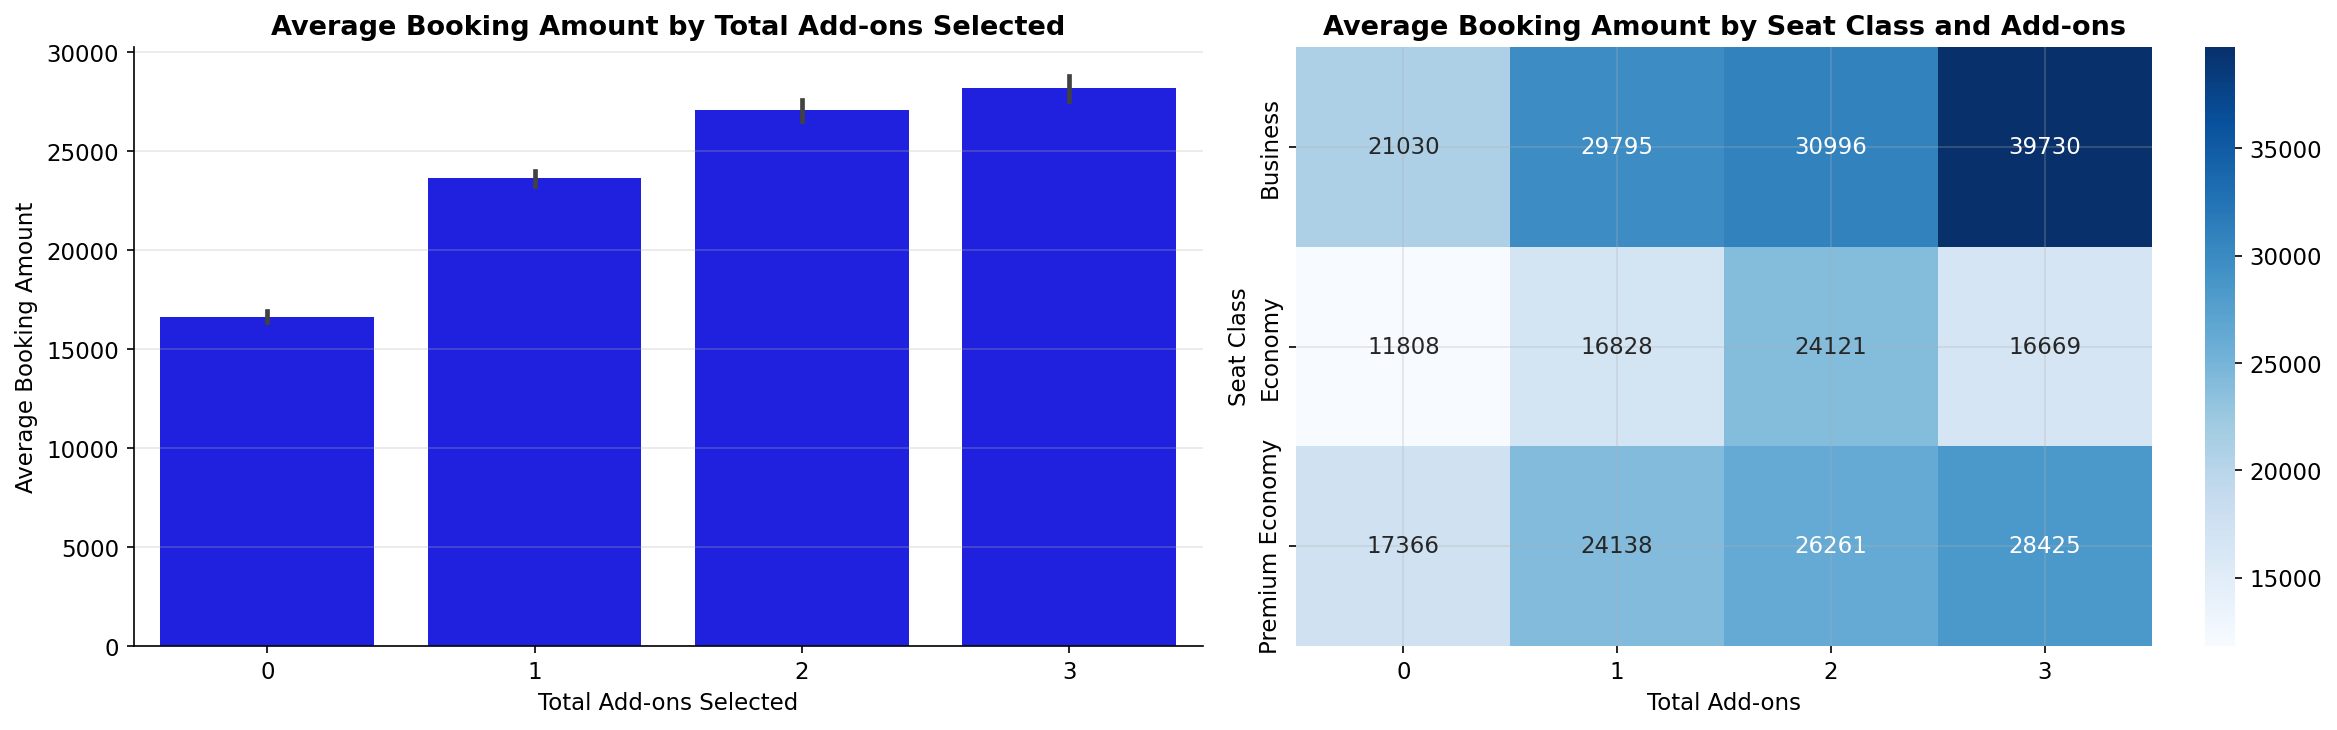

combined chart saved successfully!


In [39]:
## Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---------- Left side: Bar plot -------------  
sns.barplot(x='total_add_ons',y='booking_amount',data=df_complete,color='blue',ax=axes[0])
axes[0].set_title('Average Booking Amount by Total Add-ons Selected')
axes[0].set_xlabel('Total Add-ons Selected')
axes[0].set_ylabel('Average Booking Amount')

# ---------- Right side: Heatmap -------------
addon_pivot = df_complete.pivot_table(values='booking_amount',index='seat_class',columns='total_add_ons',aggfunc='mean')
sns.heatmap(addon_pivot,annot=True,fmt=".0f",cmap='Blues',ax=axes[1])
axes[1].set_title('Average Booking Amount by Seat Class and Add-ons')   
axes[1].set_xlabel('Total Add-ons')
axes[1].set_ylabel('Seat Class')

#Final layout adjustments
plt.tight_layout()
plt.savefig('chart_09_h4_combined_add_on_analysis.png', bbox_inches='tight')
plt.show()

print('combined chart saved successfully!')

 ### Observation: H4 - Hypothesis ( Supported ) 
- There is a clear positive relationship between number of add-ons selected and average booking amount.  
- This holds across all seat classes (confirmed in the heatmap).  
- Actionable insight: Bundling add-ons ("Baggage + Seat + Meal" bundle at a small discount) is a proven revenue lever.  
- Priority should be upselling to customers currently selecting 0 or 1 add-ons.

### Hypothesis: 5 "Flight day influences booking trends"

In [40]:
# Total booking per day
booking_day_count = df['flight_day'].value_counts().reindex(day_order)

# Completion rate per day
completion_rate_day = df.groupby('flight_day')['booking_complete'].mean().reindex(day_order).round(2) * 100

# Average booking amount per day
avg_booking_day = (df_complete.groupby('flight_day')['booking_amount'].mean().reindex(day_order).round(0))

day_summary = pd.DataFrame({'Total_Bookings': booking_day_count, 'Completion_Rate (%)': completion_rate_day, 'Average_Booking_Amount': avg_booking_day})
print(day_summary)

            Total_Bookings  Completion_Rate (%)  Average_Booking_Amount
flight_day                                                             
Mon                   8102                 15.0                 23512.0
Tue                   7673                 15.0                 23260.0
Wed                   7674                 16.0                 23112.0
Thu                   7424                 15.0                 23320.0
Fri                   6761                 14.0                 23500.0
Sat                   5812                 15.0                 27740.0
Sun                   6554                 14.0                 28819.0


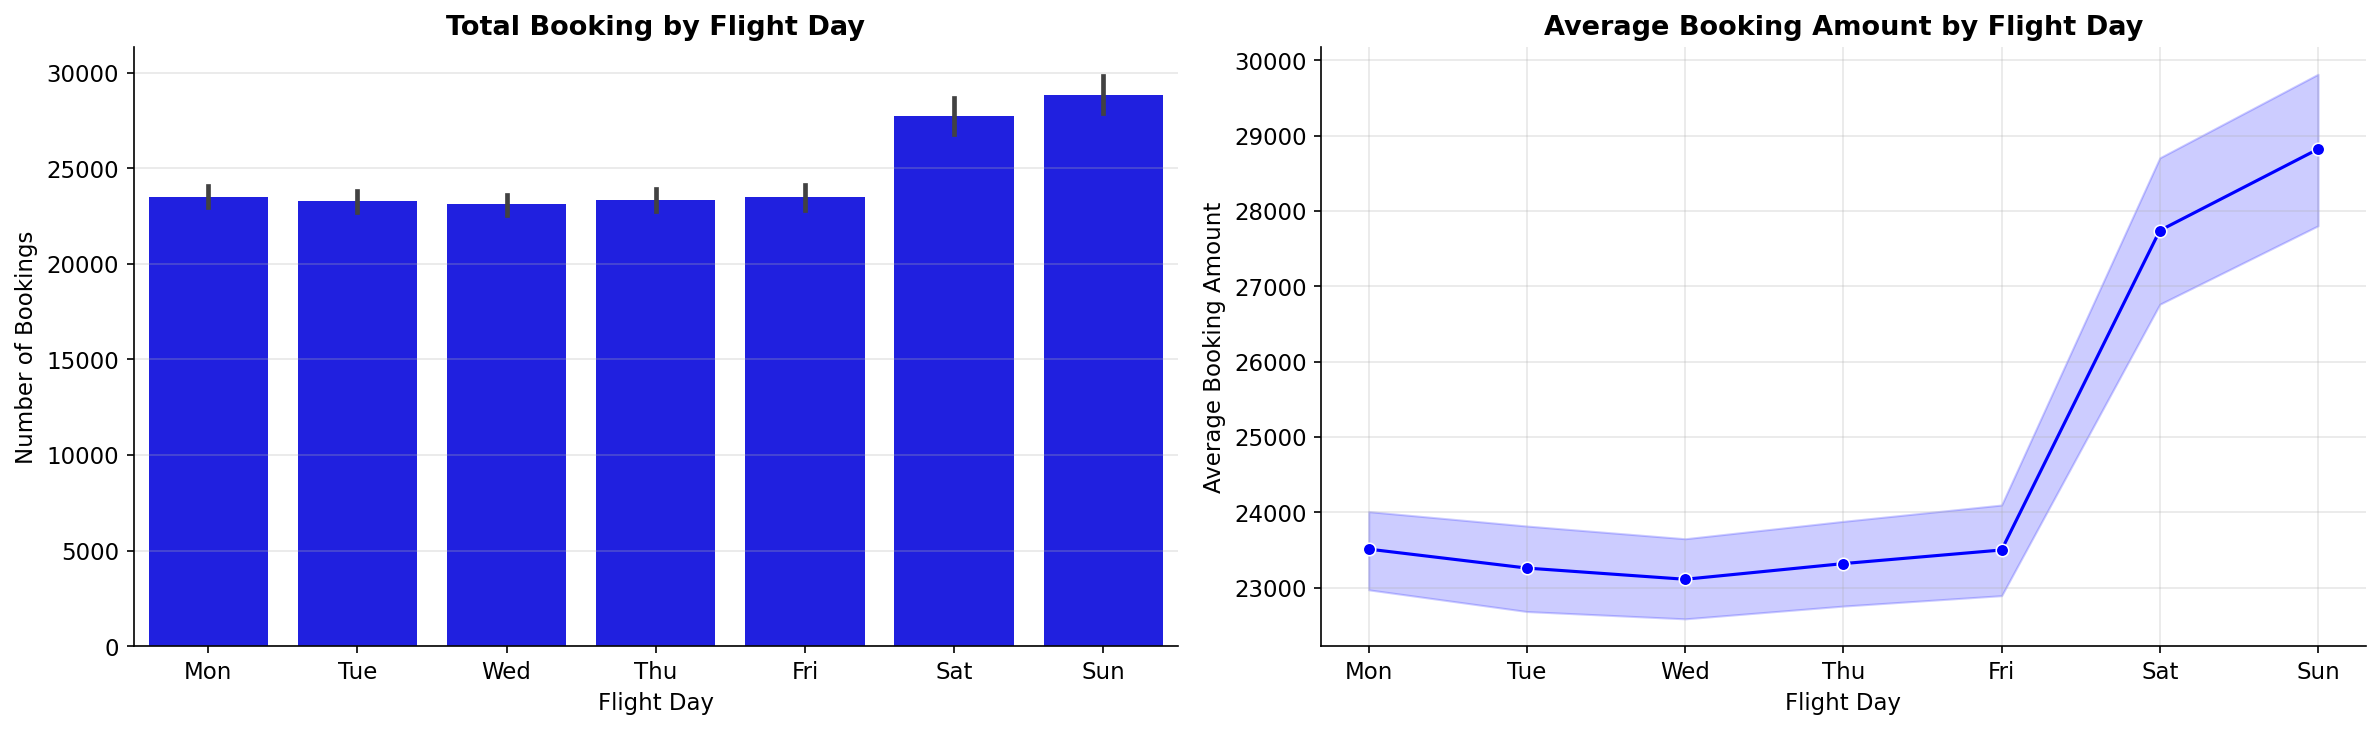

combined chart saved successfully!


In [41]:
# Combine chart for day of week analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------- Left Side: Bar Plot -----------
sns.barplot(x='flight_day',y='booking_amount',data=df_complete,order=day_order,color='blue',ax=axes[0])
axes[0].set_title('Total Booking by Flight Day')
axes[0].set_xlabel('Flight Day')
axes[0].set_ylabel('Number of Bookings')

# ----------- Right Side: Line Plot -----------
sns.lineplot(x='flight_day',y='booking_amount',data=df_complete,hue_order=day_order,color='blue',marker='o',ax=axes[1])
axes[1].set_title('Average Booking Amount by Flight Day')
axes[1].set_xlabel('Flight Day')
axes[1].set_ylabel('Average Booking Amount')
axes[1].set_xticks(range(len(day_order)))
axes[1].set_xticklabels(day_order)
axes[1].grid(True)

# Final layout adjustments
plt.tight_layout()
plt.savefig('chart_10_h5_combined_flight_day_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('combined chart saved successfully!')

### Observation: H5 - Hypothesis ( Not Supported )
- Booking counts are broadly uniform across all days of the week - no day shows a significant spike or drop.  
- Average booking amounts also fluctuate within a narrow band with no clear pattern.  
- Key insight: Flight day is not a meaningful predictor of booking volume or value.  
- Dynamic pricing by day of week would likely have minimal impact on revenue.

## - Summary of Finding And Business Recommendations

In [42]:
# Hypothesis Summary Table
summary = pd.DataFrame({
    'Hypothesis': ['H1: Business class = longer lead time',
                   'H2: Longer stay = higher booking amount',
                   'H3: Sales channel influences amount',
                   'H4: More add-ons = higher booking amount',
                   'H5: Flight day influences booking trends'],
    'Result': ['Not Supported', 'Weak/Not Supported', 
               'Partially Supported', 'Supported', 'Inconclusive'],
    'Key Finding': ['Lead times similar across all classes',
                    'Correlation is near zero',
                    'Internet drives ~92% of revenue',
                    'Higher add-ons = higher average amount',
                    'No strong pattern by day of week']
})
print(summary.to_string(index=False))

                              Hypothesis              Result                            Key Finding
   H1: Business class = longer lead time       Not Supported  Lead times similar across all classes
 H2: Longer stay = higher booking amount  Weak/Not Supported               Correlation is near zero
     H3: Sales channel influences amount Partially Supported        Internet drives ~92% of revenue
H4: More add-ons = higher booking amount           Supported Higher add-ons = higher average amount
H5: Flight day influences booking trends        Inconclusive       No strong pattern by day of week


## Business Recommendations

Based on the analysis of 50,000 of Indigo Airlines Booking records:

---
### 1. Priority: Fix the Booking Completion Rate 
- **only 14.9% of bookings are completed**  85% of customers start a booking and do not start.

- Investigate where customers drop off in the booking funnel (which step, which device, which route).
- Implement abandoned-booking email reminders within 24 hours.
- Simplify the payment flow - fewer steps = more completions.
- **Potential impact:** Even a 5% improvement in completion rate would add thousands of additional bookings.

---

### 2. Invest in Mobile Experience
- **Internet drives 92% of revenue.** Mobile is under-performing relative to its user base.

- Mobile users are booking but completing less - prioritise a smoother mobile checkout.
- Consider a dedicated app with saved payment methods and one-tap booking.
- Test mobile-exclusive promotions to shift conversion behaviour.

---

### 3. Promote Add-on Bundles
- **H4 is the only fully supported hypothesis** - (add-ons directly and reliably lift booking value)

- Create a "Smart Traveller Bundle" (Baggage + Seat + Meal) at a small discount.
- Display add-ons prominently during checkout - not at the end.
- Target customers selecting 0 add-ons with a post-booking upsell offer.

---

### 4. No Action Needed on Pricing by Day or Advance Booking Incentives
- **H1, H5 not supported** - day of week and purchase lead time have no meaningful impact on booking amount.

- Do not invest in day-of-week dynamic pricing - the data does not support it.
- Advance booking discounts may not be necessary - customers book at similar lead times regardless of class.

---

### 5. Improve Data Quality
- Multiple data quality issues found: **no_data**, **not_set**, inconsistent **trip_type** values, missing **flight_duration_planned**.

- Enforce validated dropdown inputs in the booking system for **sales_channel** and **trip_type**.
- Investigate the 118 rows with missing **flight_duration_planned** - are these data entry failures?
- Add a required field for **booking_origin** to eliminate **not_set**.

---

*Analysis by: Vaishali Parmar | Source: Indigo Customer Booking Dataset (n = 50,000) | May - 2026*

---
